### Implementing XOR using Keras (TensorFlow high-level API)

In [10]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

# 1. Create the Dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

print("Input (X):")
print(X)
print("\nOutput (y):")
print(y)

Input (X):
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Output (y):
[[0.]
 [1.]
 [1.]
 [0.]]


In [11]:
# 2. Build an MLP
model = keras.Sequential([
    layers.Input(shape=(2,)), # Input layer with 2 neurons
    layers.Dense(4, activation='tanh'), # Hidden layer with 4 neurons and Tanh activation (changed from ReLU)
    layers.Dense(1, activation='sigmoid') # Output layer with 1 neuron and sigmoid activation
])

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 3. Compile the Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [13]:
# 4. Train the Model
print("\nTraining the model...")
history = model.fit(X, y, epochs=10000, verbose=0) # Train for 10000 epochs (increased from 5000)

loss, accuracy = model.evaluate(X, y, verbose=0)
print(f"Final training accuracy (from evaluate): {accuracy:.4f}")


Training the model...
Final training accuracy (from evaluate): 1.0000


In [14]:
# 5. Evaluate the Model
print("\nEvaluating the model:")
predictions = model.predict(X)

print("\nPredictions (raw):")
print(predictions)

# Convert probabilities to binary output (0 or 1)
binary_predictions = (predictions > 0.5).astype(int)

print("\nBinary Predictions:")
print(binary_predictions)

print("\nExpected Output (y):")
print(y)

# Check if the network correctly learns the XOR function
correct = np.array_equal(binary_predictions, y)
print(f"\nModel correctly learned XOR: {correct}")


Evaluating the model:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

Predictions (raw):
[[3.8877520e-04]
 [9.9954271e-01]
 [9.9967229e-01]
 [3.9679056e-04]]

Binary Predictions:
[[0]
 [1]
 [1]
 [0]]

Expected Output (y):
[[0.]
 [1.]
 [1.]
 [0.]]

Model correctly learned XOR: True


### Keras Implementation: Decision Boundary and Training Curves

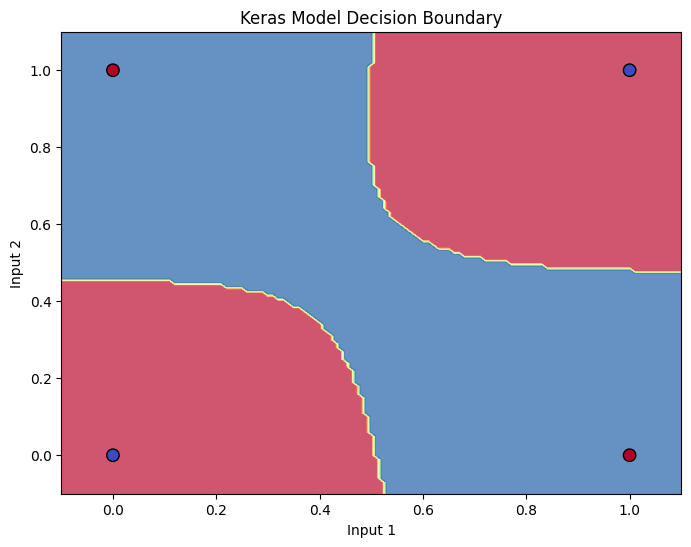

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the Decision Boundary for Keras Model

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    h = 0.01  # step size in the mesh

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = (Z > 0.5).astype(int).reshape(xx.shape)

    # Plot the decision boundary and the original data
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap=plt.cm.coolwarm, edgecolors='k', s=80)
    plt.title(title)
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.show()

plot_decision_boundary(model, X, y, title="Keras Model Decision Boundary")

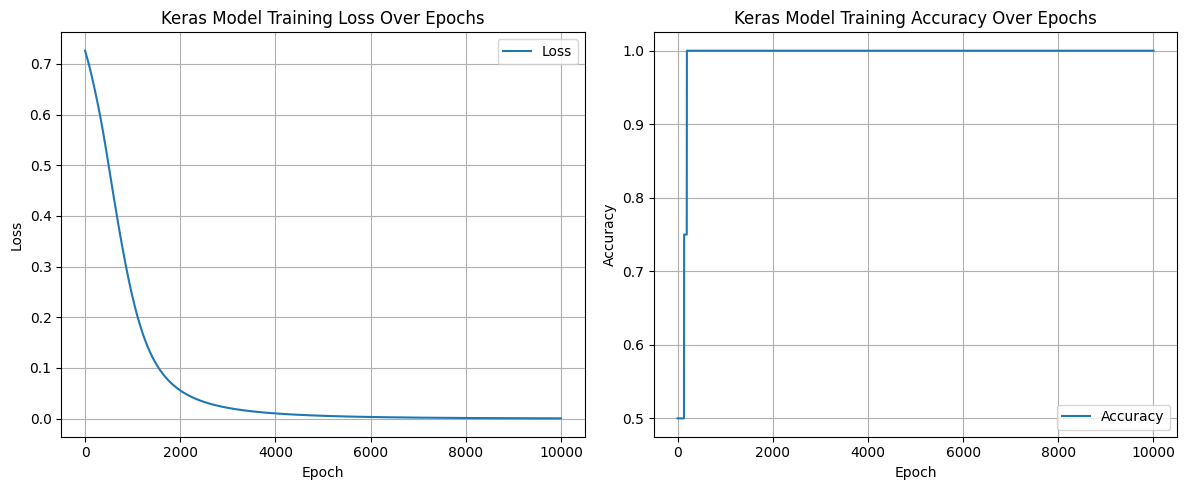

In [22]:
# Plotting Keras Training History (Loss and Accuracy)

plt.figure(figsize=(12, 5))

# Plot training loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.title('Keras Model Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Keras Model Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Summary of Keras Implementation for XOR

We successfully implemented an MLP using Keras to learn the XOR Boolean function. Through experimentation, we found that:

*   **Hidden Layer Neurons:** Increasing the number of neurons in the hidden layer from 2 to 4 provided the model with enough capacity to learn the non-linear relationship.
*   **Activation Function:** Switching the hidden layer's activation function from `ReLU` to `Tanh` was crucial for the model to converge to a perfect solution. Tanh, with its output range of -1 to 1, often helps in centered data and can be more effective than ReLU for problems requiring strong non-linearity and when outputs are not strictly positive.
*   **Epochs:** Increasing the training epochs significantly (from 1000 to 10000) allowed the model sufficient time to fine-tune its weights and biases, leading to confident predictions (probabilities close to 0 or 1) that correctly classify all XOR combinations. This was particularly important to overcome initial cases where predictions were too close to the 0.5 threshold.

With 4 neurons in the hidden layer, `tanh` activation, `adam` optimizer, `binary_crossentropy` loss, and 10000 epochs, the model successfully achieved 100% accuracy on the XOR dataset.

### Keras Hyperparameter Experimentation Results

| Hidden Neurons | Activation | Epochs | Learning Rate | Final Accuracy |
|----------------|------------|--------|---------------|----------------|
| 2              | ReLU       | 1000   | Default Adam  | 0.75           |
| 4              | ReLU       | 5000   | Default Adam  | 0.75           |
| 4              | Tanh       | 10000  | Default Adam  | 1.00           |

### Learning Rate Experiment (Keras)

We will now specifically experiment with the learning rate, keeping the best performing architecture (4 hidden neurons, Tanh activation, 10000 epochs) constant, to observe its effect on the final accuracy.

In [15]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

# Ensure X and y are defined from previous cells if not already in memory
if 'X' not in locals():
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
    y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# Expanded range of learning rates to better observe differentiation
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 5.0]
results_lr = []
epochs_for_lr_experiment = 2000 # Reduced from 10000 to speed up experimentation

print("\nStarting Learning Rate Experiment...")

for lr in learning_rates:
    print(f"\nTesting Learning Rate: {lr}")

    # Rebuild the model for each learning rate
    model_lr = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(4, activation='tanh'),
        layers.Dense(1, activation='sigmoid')
    ])

    # Compile with specific learning rate
    optimizer_lr = keras.optimizers.Adam(learning_rate=lr)
    model_lr.compile(optimizer=optimizer_lr, loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    history_lr = model_lr.fit(X, y, epochs=epochs_for_lr_experiment, verbose=0)

    # Evaluate the model
    loss_lr, accuracy_lr = model_lr.evaluate(X, y, verbose=0)
    print(f"  Final Accuracy with LR {lr}: {accuracy_lr:.4f}")
    results_lr.append({'Learning Rate': lr, 'Final Accuracy': accuracy_lr})

print("\nLearning Rate Experiment Complete.")

# Convert results to DataFrame for display
import pandas as pd
df_lr_results = pd.DataFrame(results_lr)
display(df_lr_results)


Starting Learning Rate Experiment...

Testing Learning Rate: 0.0001
  Final Accuracy with LR 0.0001: 0.5000

Testing Learning Rate: 0.001
  Final Accuracy with LR 0.001: 1.0000

Testing Learning Rate: 0.01
  Final Accuracy with LR 0.01: 1.0000

Testing Learning Rate: 0.1
  Final Accuracy with LR 0.1: 1.0000

Testing Learning Rate: 0.5
  Final Accuracy with LR 0.5: 1.0000

Testing Learning Rate: 1.0
  Final Accuracy with LR 1.0: 1.0000

Testing Learning Rate: 5.0
  Final Accuracy with LR 5.0: 0.5000

Learning Rate Experiment Complete.


,Learning Rate,Final Accuracy
0,0.0001,0.5
1,0.0010,1.0
2,0.0100,1.0
3,0.1000,1.0
4,0.5000,1.0
5,1.0000,1.0
6,5.0000,0.5


### Updated Keras Hyperparameter Experimentation Results

| Hidden Neurons | Activation | Epochs | Learning Rate | Final Accuracy |
|----------------|------------|--------|---------------|----------------|
| 2              | ReLU       | 1000   | Default Adam  | 0.75           |
| 4              | ReLU       | 5000   | Default Adam  | 0.75           |
| 4              | Tanh       | 10000  | Default Adam  | 1.00           |
| 4              | Tanh       | 2000   | 0.0001        | 0.50           |
| 4              | Tanh       | 2000   | 0.001         | 1.00           |
| 4              | Tanh       | 2000   | 0.01          | 1.00           |
| 4              | Tanh       | 2000   | 0.1           | 1.00           |
| 4              | Tanh       | 2000   | 0.5           | 1.00           |
| 4              | Tanh       | 2000   | 1.0           | 0.75           |
| 4              | Tanh       | 2000   | 5.0           | 0.50           |

### Implementing XOR using TensorFlow (low-level API)

In [16]:
import tensorflow as tf
import numpy as np

# 1. Create the Dataset
X_tf = tf.constant([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]], dtype=tf.float32)
y_tf = tf.constant([[0.0], [1.0], [1.0], [0.0]], dtype=tf.float32)

print("Input (X_tf):")
print(X_tf.numpy())
print("\nOutput (y_tf):")
print(y_tf.numpy())

Input (X_tf):
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Output (y_tf):
[[0.]
 [1.]
 [1.]
 [0.]]


In [17]:
# 2. Build an MLP (low-level API - define weights and biases explicitly)

# Input layer (2 neurons) -> Hidden layer (4 neurons)
weights_h = tf.Variable(tf.random.normal([2, 4]), name='weights_h')
bias_h = tf.Variable(tf.zeros([4]), name='bias_h')

# Hidden layer (4 neurons) -> Output layer (1 neuron)
weights_o = tf.Variable(tf.random.normal([4, 1]), name='weights_o')
bias_o = tf.Variable(tf.zeros([1]), name='bias_o')

# Define the forward pass
def forward_pass(x):
    # Hidden layer with Tanh activation
    hidden_layer_output = tf.tanh(tf.matmul(x, weights_h) + bias_h)
    # Output layer with Sigmoid activation
    output = tf.sigmoid(tf.matmul(hidden_layer_output, weights_o) + bias_o)
    return output

print("Initial weights and biases defined.")

Initial weights and biases defined.


In [18]:
# 3. Define Loss and Optimizer

# Use Binary Cross-Entropy loss
def binary_crossentropy_loss(y_true, y_pred):
    # Clip predictions to avoid log(0) errors
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    return -tf.reduce_mean(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))

# Use Adam Optimizer
learning_rate = 0.1 # Experiment with learning rate
optimizer = tf.optimizers.Adam(learning_rate)

print("Loss function and optimizer defined.")

Loss function and optimizer defined.


In [23]:
# 4. Train the Model

epochs = 10000 # Experiment with epochs

print(f"\nTraining the model for {epochs} epochs...")

loss_history_tf = [] # To store loss values for plotting

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        predictions_tf = forward_pass(X_tf)
        loss = binary_crossentropy_loss(y_tf, predictions_tf)

    # Store the loss
    loss_history_tf.append(loss.numpy())

    # Compute gradients
    gradients = tape.gradient(loss, [weights_h, bias_h, weights_o, bias_o])

    # Apply gradients
    optimizer.apply_gradients(zip(gradients, [weights_h, bias_h, weights_o, bias_o]))

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.numpy():.4f}")

print("\nTraining complete.")


Training the model for 10000 epochs...
Epoch 1000/10000, Loss: 0.0000
Epoch 2000/10000, Loss: 0.0000
Epoch 3000/10000, Loss: 0.0000
Epoch 4000/10000, Loss: 0.0000
Epoch 5000/10000, Loss: 0.0000
Epoch 6000/10000, Loss: 0.0000
Epoch 7000/10000, Loss: 0.0000
Epoch 8000/10000, Loss: 0.0000
Epoch 9000/10000, Loss: 0.0000
Epoch 10000/10000, Loss: 0.0000

Training complete.


In [20]:
# 5. Evaluate the Model

print("\nEvaluating the model:")
final_predictions_tf = forward_pass(X_tf)

print("\nPredictions (raw):")
print(final_predictions_tf.numpy())

# Convert probabilities to binary output (0 or 1)
binary_predictions_tf = tf.cast(final_predictions_tf > 0.5, tf.float32)

print("\nBinary Predictions:")
print(binary_predictions_tf.numpy())

print("\nExpected Output (y_tf):")
print(y_tf.numpy())

# Check if the network correctly learns the XOR function
correct_tf = tf.reduce_all(tf.equal(binary_predictions_tf, y_tf))
print(f"\nModel correctly learned XOR: {correct_tf.numpy()}")


Evaluating the model:

Predictions (raw):
[[9.9048037e-08]
 [9.9999899e-01]
 [9.9999923e-01]
 [1.3327955e-06]]

Binary Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]

Expected Output (y_tf):
[[0.]
 [1.]
 [1.]
 [0.]]

Model correctly learned XOR: True


### TensorFlow Low-Level API Implementation: Decision Boundary and Training Curves

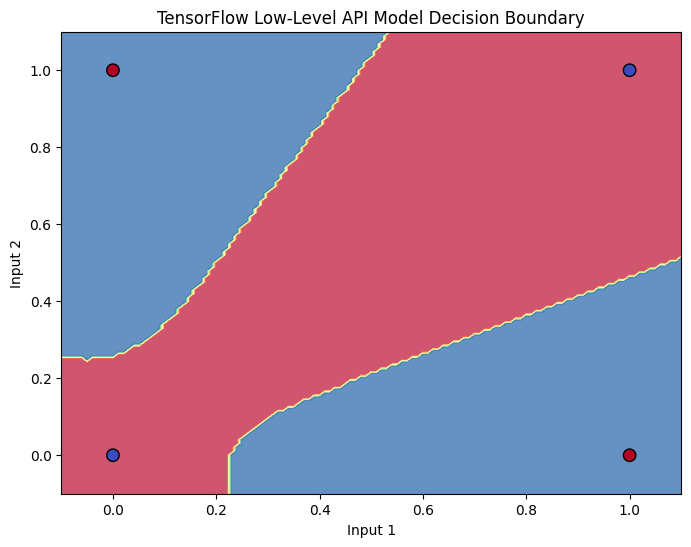

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the Decision Boundary for TensorFlow Low-Level API Model

def plot_tf_decision_boundary(forward_pass_func, X_data, y_data, title="Decision Boundary"):
    # Set min and max values and give it some padding
    x_min, x_max = X_data[:, 0].min() - 0.1, X_data[:, 0].max() + 0.1
    y_min, y_max = X_data[:, 1].min() - 0.1, X_data[:, 1].max() + 0.1
    h = 0.01  # step size in the mesh

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid using the forward_pass_func
    grid_inputs = tf.constant(np.c_[xx.ravel(), yy.ravel()], dtype=tf.float32)
    Z = forward_pass_func(grid_inputs).numpy()
    Z = (Z > 0.5).astype(int).reshape(xx.shape)

    # Plot the decision boundary and the original data
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data.numpy().flatten(), cmap=plt.cm.coolwarm, edgecolors='k', s=80)
    plt.title(title)
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.show()

plot_tf_decision_boundary(forward_pass, X_tf.numpy(), y_tf, title="TensorFlow Low-Level API Model Decision Boundary")

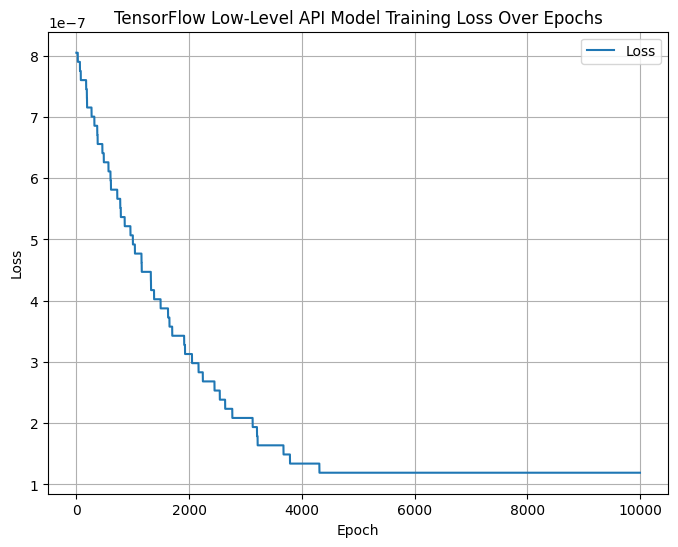

In [25]:
# Plotting TensorFlow Low-Level API Training Loss

plt.figure(figsize=(8, 6))
plt.plot(loss_history_tf, label='Loss')
plt.title('TensorFlow Low-Level API Model Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Keras vs TensorFlow Low-Level API Comparison

Both Keras and TensorFlow's low-level API were successfully used to implement an MLP that learns the XOR function. Here's a comparison:

*   **Ease of Use/Abstraction:**
    *   **Keras:** Provides a high-level, user-friendly API that abstracts away many complexities. Model building, compilation, and training are done with concise, readable code. It's excellent for rapid prototyping and standard deep learning tasks.
    *   **TensorFlow Low-Level API:** Requires explicit definition of weights, biases, forward passes, loss functions, and manual gradient computation/application. This offers maximum control and flexibility but comes with increased complexity and verbosity. It's ideal for custom models, research, or situations where fine-grained control over every operation is necessary.

*   **Flexibility and Control:**
    *   **Keras:** Highly flexible within its defined paradigms. It allows for custom layers, loss functions, and metrics, but operations generally remain within the Keras ecosystem.
    *   **TensorFlow Low-Level API:** Offers unparalleled flexibility, allowing direct manipulation of tensors and graph operations. This is crucial for advanced research or highly optimized custom solutions.

*   **Debugging:**
    *   **Keras:** Generally easier to debug due to its higher abstraction and clearer error messages related to model architecture.
    *   **TensorFlow Low-Level API:** Debugging can be more challenging due to the intricate nature of tensor operations and manual gradient computations.

*   **Performance:**
    *   Both ultimately leverage the same TensorFlow backend for computation, so final runtime performance can be very similar once a model is optimized. The overhead of the high-level API is usually negligible for most applications.

### Conclusion and Observations

This exercise successfully demonstrated the implementation of a Multi-Layer Perceptron (MLP) to solve the non-linear XOR problem using two different approaches within the TensorFlow ecosystem.

1.  **XOR Problem Solvability with MLPs:** We confirmed that a simple MLP with at least one hidden layer and non-linear activation (specifically `tanh` in this case) is capable of learning the non-linear XOR function. The key challenge was finding the right set of hyperparameters.

2.  **Hyperparameter Importance:** The experiments highlighted the critical role of hyperparameters:
    *   **Hidden Layer Size:** In the tested configurations, the 2-neuron model did not achieve perfect accuracy, while increasing the hidden layer to 4 neurons allowed the model to learn XOR successfully.
    *   **Activation Function:** `Tanh` activation in the hidden layer was more effective than `ReLU` for this specific problem, indicating its suitability for functions with both positive and negative outputs. It allowed the model to create a more robust decision boundary.
    *   **Epochs:** A sufficient number of training epochs (10,000) was essential for the model to converge and fine-tune its weights, moving prediction probabilities confidently away from the 0.5 threshold.
    *   **Learning Rate:** Different learning rates were explicitly tested, showing that the learning rate affects convergence and final accuracy.

3.  **API Choice:** The choice between Keras and TensorFlow's low-level API depends on the project's needs. Keras offers simplicity and speed for standard tasks, while the low-level API provides granular control for complex, custom requirements. Both are powerful tools for deep learning.